# 05. 糖鎖エピトープ生合成遺伝子に絞った PCA（絶対量）

## 問い

`04_absolute_glycogene_pca` で、絶対量の glycogene 385 次元では
**細胞株が分散の 63.7%、薬剤が実質 6.3%** を説明することが分かった。

本ノートは、この空間を **エピトープ辞書の遺伝子だけ**（`RAW.GLYCOEPITOPE.VW_EPITOPE_GLYCOGENE`、
57遺伝子）に絞ると何が変わるかを見る。論文が扱う単位は glycogene 全体ではなくエピトープなので、
その部分空間で細胞株／薬剤の寄与がどう変わるかは設計判断に直結する。

## データ

`04` と同じ `data/processed/abs_glyco_*.parquet`（24 h / 10 uM、絶対量）。
抽出経緯は `04` の冒頭を参照。

In [1]:
import subprocess, pathlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

rcParams['font.family'] = ['Hiragino Sans', 'sans-serif']
rcParams['axes.unicode_minus'] = False
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'

ROOT = pathlib.Path('/Users/koreedatatsuya/research/glyco_epitope_3rd_paper')
PROC = ROOT / 'data' / 'processed'
FIGDIR = ROOT / 'results' / 'figures'
META_COLS = ['cell', 'pertname', 'timepoint', 'dose', 'idx']
rng = np.random.default_rng(0)

LINEAGE = {'HEPG2': '肝', 'PHH': '肝(正常)', 'HUH7': '肝',
           'HCC515': '肺', 'A549': '肺', 'MCF7': '乳', 'MDAMB231': '乳', 'MCF10A': '乳(正常)',
           'PC3': '前立腺', 'VCAP': '前立腺', 'A375': 'メラノーマ', 'HT29': '大腸',
           'HELA': '子宮頸', 'YAPC': '膵', 'U2OS': '骨', 'THP1': '血液', 'NPC': '神経前駆',
           'HA1E': '腎(正常不死化)'}


def savefig(name):
    """成果物ごとのフォルダに PNG/PDF/SVG を保存する（/figure-style の規約）"""
    outdir = FIGDIR / name
    outdir.mkdir(parents=True, exist_ok=True)
    for ext in ('png', 'pdf', 'svg'):
        plt.savefig(outdir / f'{name}.{ext}', dpi=200, bbox_inches='tight')


def ss_between(M, labels):
    """群間平方和"""
    lab = np.asarray(labels)
    return sum(len(M[lab == l]) * ((M[lab == l].mean(0) - M.mean(0)) ** 2).sum()
               for l in np.unique(lab))

## 1. エピトープ辞書の遺伝子を取得

In [2]:
q = """SELECT DISTINCT HGNC_SYMBOL AS gene FROM RAW.GLYCOEPITOPE.VW_EPITOPE_GLYCOGENE
       WHERE HGNC_SYMBOL IS NOT NULL ORDER BY 1"""
out = subprocess.run(['snow', 'sql', '-c', 'admin', '-q', q, '--format', 'csv'],
                     capture_output=True, text=True, check=True)
epi_all = sorted(pd.read_csv(io.StringIO(out.stdout)).GENE.unique())
print(f'エピトープ辞書の遺伝子: {len(epi_all)}')

エピトープ辞書の遺伝子: 57


## 2. 読み込みと QC

外れ値判定は **細胞株ごと**に行う（プール判定だと PHH が85%脱落する。`04` 参照）。

In [3]:
d = pd.concat([pd.read_parquet(PROC / 'abs_glyco_16cell_24h.parquet'),
               pd.read_parquet(PROC / 'abs_glyco_liver_24h.parquet')], ignore_index=True)
genes = [c for c in d.columns if c not in META_COLS]
X = d[genes].astype(float)

keep = np.ones(len(d), bool)
for c, ix in d.groupby('cell').groups.items():
    ix = np.asarray(ix)
    sub = X.loc[ix]
    med = sub.median()
    mad = (sub - med).abs().median() * 1.4826 + 1e-9
    keep[ix] = ~((((sub - med) / mad).abs() > 10).mean(axis=1) > 0.05).values
d, X = d[keep].reset_index(drop=True), X[keep].reset_index(drop=True)

agg = X.groupby([d.cell, d.pertname]).median()
cell = np.asarray(agg.index.get_level_values(0))
pert = np.asarray(agg.index.get_level_values(1))

epi = [g for g in epi_all if g in genes]
missing = [g for g in epi_all if g not in genes]
print(f'(細胞,薬剤) {len(agg):,} 組 / 細胞 {len(set(cell))} / 薬剤 {len(set(pert)):,}')
print(f'エピトープ遺伝子 {len(epi_all)} 中 抽出済み385 glycogene に含まれる {len(epi)}（欠け: {missing}）')

(細胞,薬剤) 13,212 組 / 細胞 18 / 薬剤 1,435
エピトープ遺伝子 57 中 抽出済み385 glycogene に含まれる 56（欠け: ['FUT5']）


## 3. 分散分解 — 385遺伝子版 と エピトープ版 の比較

薬剤の寄与は群の数（1,435）が多いほど偶然でも上がるので、ラベル置換で帰無を引く。

In [4]:
rows = []
for label, cols in [('全glycogene 385', genes), (f'エピトープ {len(epi)}', epi)]:
    M = StandardScaler().fit_transform(agg[cols].values)
    tot = ((M - M.mean(0)) ** 2).sum()
    ss_cell = ss_between(M, cell)
    Mc = M - pd.DataFrame(M, index=cell).groupby(level=0).transform('mean').values
    ss_drug = ss_between(Mc, pert)
    null_drug = np.mean([ss_between(Mc, rng.permutation(pert)) for _ in range(5)])
    Y = PCA(n_components=10).fit_transform(M)
    rows.append({'空間': label, '次元': len(cols),
                 '細胞株 %': 100 * ss_cell / tot,
                 '薬剤(実質) %': 100 * (ss_drug - null_drug) / tot,
                 '残差 %': 100 * (tot - ss_cell - ss_drug) / tot,
                 'silhouette': silhouette_score(Y, cell)})
pd.DataFrame(rows).round(2)

,空間,次元,細胞株 %,薬剤(実質) %,残差 %,silhouette
0,全glycogene 385,385,63.73,6.30,26.02,0.29
1,エピトープ 56,56,69.37,4.59,22.72,0.35


**エピトープに絞ると細胞株の分離が強くなり、薬剤の寄与は下がる。**
遺伝子数を 1/7 に減らして情報が減ったのに分離が良くなるので、単なるノイズ低減ではなく
**エピトープ生合成酵素が glycogene 全体よりさらに組織アイデンティティに固定されている**ことを意味する。

## 4. PCA と作図

寄与率 PC1-5: [0.159 0.153 0.121 0.107 0.079]


fsSelection bit 5 (bold) and head table macStyle bit 0 (bold) should match


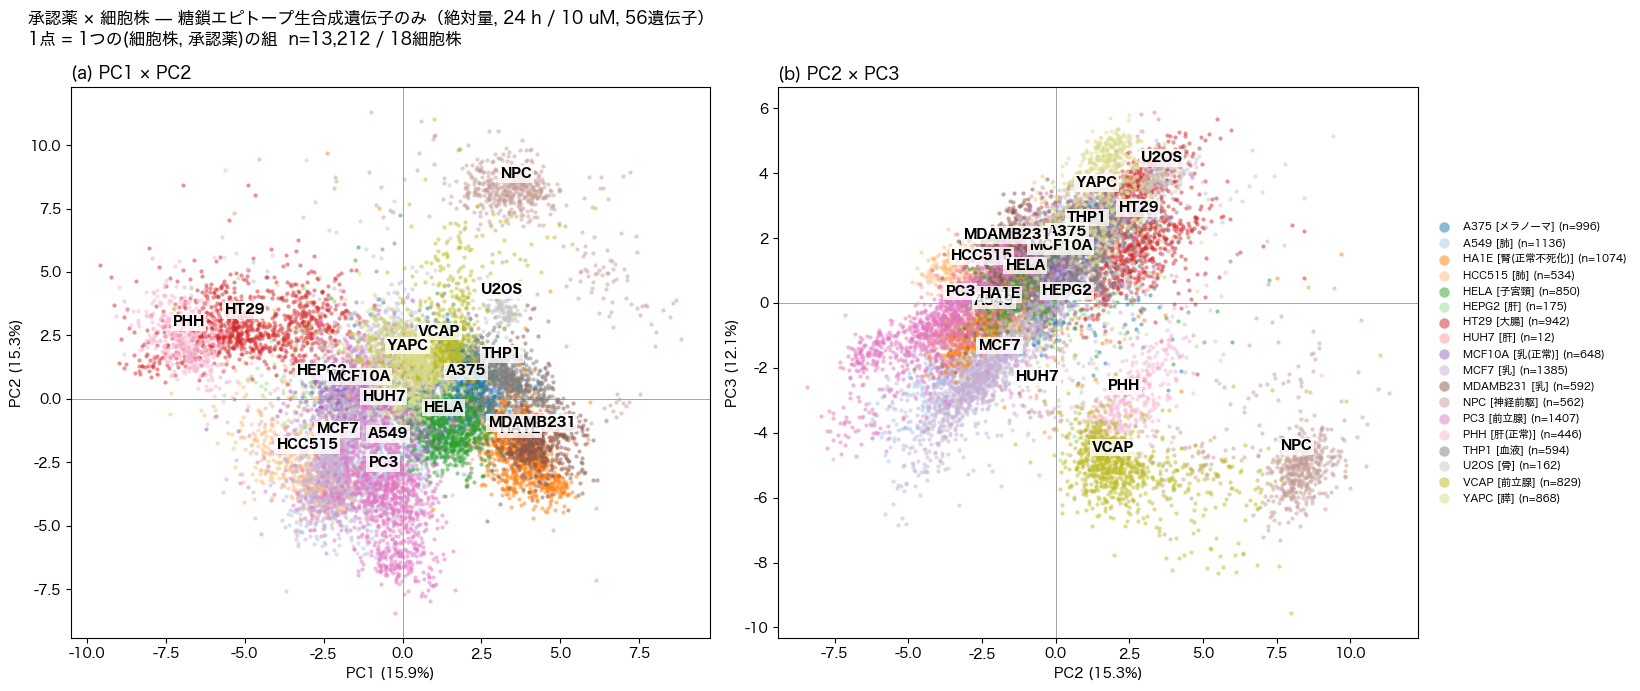

In [5]:
A = agg[epi]
M = StandardScaler().fit_transform(A.values)
pca = PCA(n_components=10).fit(M)
Y = pca.transform(M)
print('寄与率 PC1-5:', np.round(pca.explained_variance_ratio_[:5], 3))

cells_u = sorted(set(cell))
cmap = plt.get_cmap('tab20')
color = {c: cmap(i % 20) for i, c in enumerate(cells_u)}
pcs = [(0, 1), (1, 2)]
fig, axes = plt.subplots(1, 2, figsize=(16.5, 7))
for ax, (i, j) in zip(axes, pcs):
    for c in cells_u:
        m = cell == c
        ax.scatter(Y[m, i], Y[m, j], s=9, alpha=.5, color=color[c], linewidths=0,
                   label=f"{c} [{LINEAGE.get(c,'?')}] (n={m.sum()})" if (i, j) == pcs[-1] else None)
    for c in cells_u:
        m = cell == c
        ax.annotate(c, (np.median(Y[m, i]), np.median(Y[m, j])), fontsize=9.5,
                    fontweight='bold', zorder=6, xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    bbox=dict(fc='white', ec='none', alpha=.8, pad=1.2))
    ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]*100:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]*100:.1f}%)')
    ax.axhline(0, lw=.5, color='gray', zorder=0)
    ax.axvline(0, lw=.5, color='gray', zorder=0)
    ax.set_title(f'({"ab"[pcs.index((i,j))]}) PC{i+1} × PC{j+1}', loc='left')
fig.suptitle('承認薬 × 細胞株 — 糖鎖エピトープ生合成遺伝子のみ'
             f'（絶対量, 24 h / 10 uM, {len(epi)}遺伝子）\n'
             f'1点 = 1つの(細胞株, 承認薬)の組  n={len(cell):,} / {len(cells_u)}細胞株',
             x=.02, ha='left', fontsize=12)
axes[1].legend(fontsize=7.5, markerscale=2.5, frameon=False,
               loc='center left', bbox_to_anchor=(1.01, .5))
plt.tight_layout()
savefig('fig_epitope_gene_pca_24h')
plt.show()

## 5. 各主成分を駆動する遺伝子

In [6]:
L = pd.DataFrame(pca.components_[:3].T, index=A.columns, columns=['PC1', 'PC2', 'PC3'])
for pc in ['PC1', 'PC2', 'PC3']:
    s = L[pc].sort_values()
    print(f'--- {pc} ---')
    print('  正:', ', '.join(f'{g}({v:+.2f})' for g, v in s.tail(6)[::-1].items()))
    print('  負:', ', '.join(f'{g}({v:+.2f})' for g, v in s.head(6).items()))
L.round(3).to_csv(ROOT / 'results' / 'tables' / 'epitope_gene_pca_loadings.csv')

--- PC1 ---
  正: CHST10(+0.28), B3GLCT(+0.22), CHSY1(+0.22), ST3GAL3(+0.20), EXT2(+0.20), CHST3(+0.20)
  負: FUT3(-0.22), ST6GALNAC1(-0.21), FUT6(-0.19), FUT1(-0.17), ST3GAL1(-0.16), GAL3ST1(-0.16)
--- PC2 ---
  正: B3GAT1(+0.27), ST8SIA1(+0.24), B3GAT2(+0.23), ST8SIA5(+0.20), ST8SIA2(+0.19), GAL3ST3(+0.18)
  負: A4GALT(-0.26), B4GALT1(-0.25), POFUT1(-0.21), ST3GAL4(-0.21), B4GALT2(-0.19), POMGNT1(-0.19)
--- PC3 ---
  正: C1GALT1(+0.30), MGAT5(+0.26), OGT(+0.25), CHST4(+0.20), CHSY1(+0.19), B4GALT6(+0.19)
  負: B4GALT2(-0.23), GAL3ST3(-0.23), GAL3ST2(-0.23), POMT1(-0.22), MGAT3(-0.18), POFUT2(-0.16)


## 結論

### エピトープに絞ると細胞株支配がさらに強まる

| | 全glycogene 385 | エピトープ 56 |
|---|---|---|
| 細胞株 | 63.7% | **69.4%** |
| 薬剤（実質） | 6.3% | **4.6%** |
| silhouette | 0.291 | **0.352** |

**論文が狙いたいエピトープは、まさに組織アイデンティティに最も固定され、薬剤で最も動かしにくい遺伝子群だった。**
「薬剤でエピトープを再配線する」には逆風、「系統ごとの糖鎖標的性」には追い風。
`docs/paper_value.md` の汎系統ピボットを支持する。

### 主成分の解釈

- **PC1** … 正 CHST10 / CHSY1 / CHST3 / EXT2（硫酸化・GAG系）↔ 負 FUT3 / FUT6 / FUT1 / ST6GALNAC1
  （フコシル化・ムチン型）。**GAG軸 対 Lewis/ムチン軸**
- **PC2** … 正 B3GAT1 / ST8SIA1 / ST8SIA5 / ST8SIA2（ガングリオシド・ポリシアル酸＝神経系）↔
  負 A4GALT / B4GALT1 / ST3GAL4（グロボ系・基幹ガラクトシル化）。NPC が分離する軸
- **PC3** … 正 **C1GALT1 / MGAT5 / OGT**（T抗原・β1,6分岐・O-GlcNAc）↔ 負 MGAT3 / POMT1 / GAL3ST2。
  **悪性度軸**と読める。`04` の HEPG2 vs PHH で上位に来た C1GALT1・MGAT5 がそのまま PC3 正側に乗り、
  分岐を抑制する MGAT3 が負側にある点で整合的

## 制約

- エピトープ辞書 57 遺伝子のうち FUT5 が抽出済み 385 glycogene に無く、56 遺伝子での解析。
- 遺伝子レベルであってエピトープレベルではない。47エピトープ中31が単一遺伝子なので実質同じだが、
  複数遺伝子のエピトープ（Lewis y など）は集約していない（`docs/set_based_aggregation_feasibility.md`）。
- 24 h / 10 uM のみ。HEPG2 はこの条件で 175 薬と薄い（6 h なら 590 薬）。
- 元データは推論 RNA-seq（978 landmark の関数）。